In [18]:
#Import necessary packages
import time
import requests
import lxml.html as lx
import re
import pandas as pd
from datetime import datetime
import sqlite3 as sql
from requests.exceptions import HTTPError
import operator as op
from unidecode import unidecode
from copy import deepcopy

## SQL Overview

In [19]:
#Create SQl connection
sqlite_db_path = '../all_data/data.db'  # Name of the table to be created in SQLite
conn = sql.connect(sqlite_db_path)

In [21]:
#View BillboardChart table
pd.read_sql('''SELECT * from BillboardCharts''', conn)

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Flipperachi,FA9LA,1,None,1,1,10,02-28-2026,Billboard Arabic Hot 100
1,DYSTINCT,Yama,2,None,2,1,17,02-28-2026,Billboard Arabic Hot 100
2,Vanco Featuring AYA,Ma Tnsani,3,None,3,2,29,02-28-2026,Billboard Arabic Hot 100
3,"Lege-Cy, Ghaliaa",Msh Awl Marra,4,None,7,4,3,02-28-2026,Billboard Arabic Hot 100
4,DYSTINCT,Ta3al,5,None,4,3,4,02-28-2026,Billboard Arabic Hot 100
...,...,...,...,...,...,...,...,...,...
1645,Don Omar,Danza Kuduro,196,https://www.billboard.com/artist/don-omar/,-,140,37,02-28-2026,Worldwide Top 200 Songs
1646,Jimin,Who,197,https://www.billboard.com/artist/jimin/,-,1,74,02-28-2026,Worldwide Top 200 Songs
1647,Hozier,Too Sweet,198,https://www.billboard.com/artist/hozier/,-,1,98,02-28-2026,Worldwide Top 200 Songs
1648,"Shakira, Wyclef Jean",Hips Don't Lie,199,"https://www.billboard.com/artist/shakira/, htt...",-,134,20,02-28-2026,Worldwide Top 200 Songs


In [22]:
#View Spotify Weekly Streaming Charts Table
pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts''', conn).head()

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global


In [23]:
#View Apple Chart Rankings Table
pd.read_sql('''SELECT * FROM AppleChartRankings''', conn).head()

,rank,artist,song_name,chart_name,date,country
0,1,Bad Bunny,DtMF,Worldwide Apple Music Song,02-27-2026,Worldwide
1,2,Taylor Swift,The Fate of Ophelia,Worldwide Apple Music Song,02-27-2026,Worldwide
2,3,PinkPantheress,Stateside,Worldwide Apple Music Song,02-27-2026,Worldwide
3,4,Dave & Tems,Raindance,Worldwide Apple Music Song,02-27-2026,Worldwide
4,5,Olivia Dean,Man I Need,Worldwide Apple Music Song,02-27-2026,Worldwide


In [25]:
# View all distinct spotify weekly charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyWeeklyStreamingCharts''', conn)

,chart_name
0,Spotify Weekly Chart Global
1,Spotify Weekly Chart United States
2,Spotify Weekly Chart United Kingdom
3,Spotify Weekly Chart Andorra
4,Spotify Weekly Chart Argentina
...,...
72,Spotify Weekly Chart Ukraine
73,Spotify Weekly Chart United Arab Emirates
74,Spotify Weekly Chart Uruguay
75,Spotify Weekly Chart Venezuela


In [26]:
#View all distinct spotify daily charts
pd.read_sql('''SELECT DISTINCT chart_name FROM SpotifyDailyStreamingCharts''', conn)

,chart_name
0,Spotify Daily Chart Global
1,Spotify Daily Chart United States
2,Spotify Daily Chart United Kingdom
3,Spotify Daily Chart Argentina
4,Spotify Daily Chart Australia
...,...
71,Spotify Daily Chart Ukraine
72,Spotify Daily Chart United Arab Emirates
73,Spotify Daily Chart Uruguay
74,Spotify Daily Chart Venezuela


In [47]:
#View all distinct apple charts
pd.read_sql('''SELECT DISTINCT chart_name FROM AppleChartRankings''', conn)

,chart_name
0,Worldwide Apple Music Song
1,United States Apple Music Top Song
2,United Kingdom Apple Music Top Song
3,Argentina Apple Music Top Song
4,Australia Apple Music Top Song
...,...
153,Uruguay Apple Music Top Song
154,Uzbekistan Apple Music Top Song
155,Venezuela Apple Music Top Song
156,Yemen Apple Music Top Song


## Ranking Counts

In [56]:
# Store spotify weekly table for "02-26-2026" week
spotify = pd.read_sql('''SELECT * FROM SpotifyWeeklyStreamingCharts WHERE date = "02-26-2026"''', conn)

In [57]:
# Store billboard global table
global_billboard = pd.read_sql('''SELECT * from BillboardCharts WHERE chart = "Worldwide Top 200 Songs"''', conn)

In [58]:
global_billboard

,artist,song_name,rank,artist_link,last_week_rank,peak,weeks_chart,week,chart
0,Bad Bunny,DTMF,1,https://www.billboard.com/artist/bad-bunny/,1,1,59,02-28-2026,Worldwide Top 200 Songs
1,Bad Bunny,Baile Inolvidable,2,https://www.billboard.com/artist/bad-bunny/,2,2,59,02-28-2026,Worldwide Top 200 Songs
2,Bad Bunny,Nuevayol,3,https://www.billboard.com/artist/bad-bunny/,3,3,59,02-28-2026,Worldwide Top 200 Songs
3,Bad Bunny,Titi Me Pregunto,4,https://www.billboard.com/artist/bad-bunny/,5,4,71,02-28-2026,Worldwide Top 200 Songs
4,Olivia Dean,Man I Need,5,None,6,2,26,02-28-2026,Worldwide Top 200 Songs
...,...,...,...,...,...,...,...,...,...
195,Don Omar,Danza Kuduro,196,https://www.billboard.com/artist/don-omar/,-,140,37,02-28-2026,Worldwide Top 200 Songs
196,Jimin,Who,197,https://www.billboard.com/artist/jimin/,-,1,74,02-28-2026,Worldwide Top 200 Songs
197,Hozier,Too Sweet,198,https://www.billboard.com/artist/hozier/,-,1,98,02-28-2026,Worldwide Top 200 Songs
198,"Shakira, Wyclef Jean",Hips Don't Lie,199,"https://www.billboard.com/artist/shakira/, htt...",-,134,20,02-28-2026,Worldwide Top 200 Songs


In [59]:
spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DtMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
1,2,Bad Bunny,BAILE INoLVIDABLE,2,60,33278386,-10608661.0,1273769628,Spotify Weekly Chart Global,02-26-2026,Global
2,3,Djo,End of Beginning,1,106,32979053,-2245987.0,2225140553,Spotify Weekly Chart Global,02-26-2026,Global
3,4,Bad Bunny,NUEVAYoL,3,60,32180613,-10955089.0,1040380429,Spotify Weekly Chart Global,02-26-2026,Global
4,5,Olivia Dean,Man I Need,3,27,31180371,-1623349.0,792309416,Spotify Weekly Chart Global,02-26-2026,Global
...,...,...,...,...,...,...,...,...,...,...,...
14595,196,Changg,Em Không Hiểu (w/ Minh Huy),27,237,138341,-10117.0,32312825,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14596,197,Lil Zpoet,Yêu Từ Đâu Mà Ra,150,20,137045,-1849.0,3332279,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14597,198,Sơn Tùng M-TP,Chúng Ta Không Thuộc Về Nhau,60,60,137040,NaN,8636859,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam
14598,199,AMEE,MỘNG YU (w/ RPT MCK),3,76,136984,NaN,25553883,Spotify Weekly Chart Vietnam,02-26-2026,Vietnam


In [61]:
def clean_string(song_name):
    new_word = re.findall(r"(\S.*\S)(?= \(w)", song_name)
    return new_word

In [42]:
# For a song in the Billboard Global 200, retrieve all the rows in the spotify weekly table that match that song entry; create a list that stores True/False depending on whether the song in the spotify row matches the current billboard song and return this list.

#We have to clean both the spotify song name and the billboard song name so that the names can be fairly compared between tables.

def get_tables(name):
    list_add =[]
    for column in spotify["song_name"]:
        new_column = clean_string(column)
        if len(new_column) == 0:
            if op.contains(unidecode(column.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((column).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
        else:
            new_word = new_column[0]
            if op.contains(unidecode(new_word.lower()), unidecode((name).lower())) or op.contains(unidecode(name.lower()), unidecode((new_word).lower())):
                list_add.append(True)
            else:
                list_add.append(False)
    return list_add

In [43]:
# Use the get_table() function for each song in the global billboard 200 and create a data frame for each song that stores all of the different appearances of the billboard song in the different spotify weekly charts.

def billboard_spotify_song_df():
    song_count = {}
    song_df = []

    for i in range(0, global_billboard.shape[0]):
        song_name = global_billboard.iloc[i, 1]
        list_add = get_tables(song_name)
        df_song = deepcopy(spotify[list_add])
        new_song_name = clean_string(song_name)
        if len(new_song_name) != 0:
            song_name = new_song_name[0]
        new_song_name_list = [song_name] * df_song.shape[0]
        df_song['song_name'] = new_song_name_list
        temp = df_song[df_song['country'] != "Global"]
        total_listens = temp["Streams"].sum()
        song_count[i] = total_listens / 1000000
        song_df.append(df_song)
    return song_count


In [ ]:
# Create the spotify table

In [44]:
song_count_series = pd.Series(song_count).rename("total_counts")

In [45]:
bill_spotify = pd.concat(song_df)

In [46]:
bill_spotify

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DTMF,1,60,45722046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
200,1,Bad Bunny,DTMF,1,60,10565325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States
419,20,Bad Bunny,DTMF,3,9,1507125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom
660,3,Bad Bunny,DTMF,1,60,1706009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina
875,18,Bad Bunny,DTMF,3,8,947907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia
...,...,...,...,...,...,...,...,...,...,...,...
12454,197,Lana Del Rey,Young And Beautiful,4,66,49672,385.0,972713,Spotify Weekly Chart Singapore,02-26-2026,Singapore
13657,200,Lana Del Rey,Young And Beautiful,131,26,57438,-2442.0,1523825,Spotify Weekly Chart Switzerland,02-26-2026,Switzerland
14076,19,UZI,Young And Beautiful,1,5,1601220,-533917.0,16390266,Spotify Weekly Chart Turkey,02-26-2026,Turkey
14252,195,Poizi,Young And Beautiful,9,44,529068,-128838.0,68962002,Spotify Weekly Chart Turkey,02-26-2026,Turkey


In [28]:
bill_spotify['Streams'] = bill_spotify["Streams"] / 100000

In [29]:
bill_spotify[bill_spotify['song_name'].str.lower() == ("DTMF").lower()]

,rank,artist,song_name,peak,weeks,Streams,Streams+,Total,chart_name,date,country
0,1,Bad Bunny,DTMF,1,60,457.22046,-14850248.0,1549114511,Spotify Weekly Chart Global,02-26-2026,Global
200,1,Bad Bunny,DTMF,1,60,105.65325,-5205274.0,325417108,Spotify Weekly Chart United States,02-26-2026,United States
419,20,Bad Bunny,DTMF,3,9,15.07125,-702587.0,11779392,Spotify Weekly Chart United Kingdom,02-26-2026,United Kingdom
660,3,Bad Bunny,DTMF,1,60,17.06009,-440542.0,63978952,Spotify Weekly Chart Argentina,02-26-2026,Argentina
875,18,Bad Bunny,DTMF,3,8,9.47907,-311073.0,6033739,Spotify Weekly Chart Australia,02-26-2026,Australia
...,...,...,...,...,...,...,...,...,...,...,...
13791,134,Bad Bunny,DTMF,88,3,1.05941,-19589.0,345564,Spotify Weekly Chart Taiwan,02-26-2026,Taiwan
14382,125,Bad Bunny,DTMF,38,5,0.43465,-17618.0,266106,Spotify Weekly Chart Ukraine,02-26-2026,Ukraine
14461,4,Bad Bunny,DTMF,1,30,0.88181,-43908.0,1379660,Spotify Weekly Chart United Arab Emirates,02-26-2026,United Arab Emirates
14664,7,Bad Bunny,DTMF,1,60,1.14528,-26716.0,5098058,Spotify Weekly Chart Uruguay,02-26-2026,Uruguay


In [54]:
mean_spotify_country = bill_spotify.groupby("country").sum(numeric_only=True)

In [55]:
mean_spotify_country

,rank,peak,weeks,Streams,Streams+,Total
country,,,,,,
Andorra,90,52,48,0.10085,-138.0,135878
Argentina,1662,418,1662,307.13092,-6185024.0,1495546996
Australia,10363,4021,11230,749.42269,-3221435.0,6046802517
Austria,8599,3821,6224,80.36034,-581609.0,479152247
Belarus,2052,1211,1024,5.15629,43625.0,41106456
...,...,...,...,...,...,...
United Kingdom,9967,3614,10267,1167.57885,-8044004.0,9264132457
United States,8857,2613,7283,4273.71247,-50359575.0,27964848453
Uruguay,1670,626,1386,21.81119,-325828.0,103801720


In [56]:
sorted_spotify_country = mean_spotify_country["Streams"].sort_values(ascending=False).reset_index()

In [57]:
top_twenty_countries = sorted_spotify_country[1:21]

In [58]:
reverse_sorted = top_twenty_countries.sort_values(by = "Streams", ascending=True)

Text(0.5, 1.0, 'Absolute Weekly Number of Streams by Country (Top 20 Countries)')

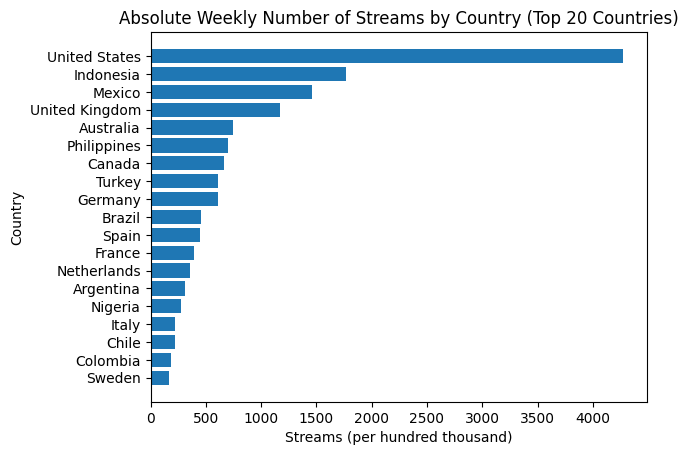

In [59]:
plt.barh(y = reverse_sorted.iloc[1:21, 0], width = reverse_sorted.iloc[1:21, 1], align = 'center')
plt.xlabel("Streams (per hundred thousand)")
plt.ylabel("Country")
plt.title("Absolute Weekly Number of Streams by Country (Top 20 Countries)")

In [178]:
bill_spotify.groupby("song_name").mean(numeric_only=True)

,rank,peak,weeks,Streams,Streams+,Total
song_name,,,,,,
(When You Gonna) Give It Up To Me,77.844444,66.844444,9.111111,5.088534,5639.116279,5.429103e+06
12 To 12,39.290323,21.516129,28.354839,9.099710,-43650.419355,2.773161e+07
4 Raws,94.863636,30.000000,16.045455,7.232222,-61481.409091,1.231461e+07
505,117.818182,32.363636,201.000000,14.798942,-70911.454545,2.934994e+08
7-3,34.833333,16.666667,9.000000,30.864987,-333553.333333,3.227344e+07
...,...,...,...,...,...,...
Young And Beautiful,123.416667,53.250000,44.083333,11.832978,-124784.666667,8.365712e+07
Yukon,133.636364,24.636364,21.909091,4.176820,-57757.818182,1.811034e+07
Zoo,98.928571,51.642857,19.928571,8.306794,-74318.928571,1.705929e+07


In [181]:
bill_spotify.groupby("song_name")["Streams"].agg(np.std)

/var/folders/4_/60ntqn4n1vj5gd579ykchny00000gn/T/ipykernel_49311/2609255448.py:1: FutureWarning: The provided callable <function std at 0x104031580> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  bill_spotify.groupby("song_name")["Streams"].agg(np.std)


song_name
(When You Gonna) Give It Up To Me    18.097533
12 To 12                             27.942738
4 Raws                               21.265900
505                                  34.155792
7-3                                  46.529629
                                       ...    
Young And Beautiful                  26.281062
Yukon                                 7.112758
Zoo                                  21.123308
like JENNIE                          28.261680
wgft                                  2.438514
Name: Streams, Length: 199, dtype: float64

In [169]:
for name in bill_spotify["song_name"].unique():
    if name not in global_billboard['song_name'].unique():
        print(name)

In [170]:
for name in global_billboard['song_name'].unique():
    if name not in bill_spotify["song_name"].unique():
        print(name)

Cuando No Era Cantante (Remix)
I Like It
We Can't Be Friends (Wait For Your Love)
La Plena (W Sound 05)
Sunflower (Spider-Man: Into The Spider-Verse)
Wrong Faces.


In [96]:
song_count_series.to_list()

[42.898095,
 33.97869,
 32.233641,
 27.166666,
 26.630105,
 30.186406,
 22.538171,
 18.331829,
 25.586032,
 31.006662,
 12.950707,
 28.873308,
 20.12908,
 19.273968,
 14.454358,
 18.335894,
 22.478187,
 16.466296,
 13.040377,
 18.548011,
 19.481079,
 15.370733,
 13.694888,
 20.840844,
 15.23478,
 12.745487,
 11.444566,
 16.301778,
 16.235728,
 11.420086,
 18.365424,
 11.99725,
 7.046373,
 9.451575,
 3.437199,
 7.792566,
 9.648757,
 20.005495,
 11.308634,
 9.449625,
 19.428553,
 12.720412,
 8.704501,
 10.229196,
 4.316606,
 7.813842,
 9.881698,
 7.790786,
 5.565975,
 9.522809,
 4.999139,
 10.231784,
 8.289274,
 5.422985,
 4.620331,
 2.078598,
 13.212217,
 10.236898,
 9.452249,
 13.524675,
 6.757257,
 3.124038,
 6.638211,
 8.645001,
 5.196325,
 7.55079,
 9.395378,
 9.230605,
 12.746536,
 7.237618,
 6.868082,
 9.316448,
 5.806606,
 2.371487,
 8.176961,
 2.182226,
 7.490564,
 6.177721,
 4.594502,
 3.731072,
 2.338987,
 10.08371,
 7.339379,
 7.539832,
 9.21328,
 7.719419,
 1.199127,
 1.8807

Text(0.5, 1.0, 'Song Rank v. Streams')

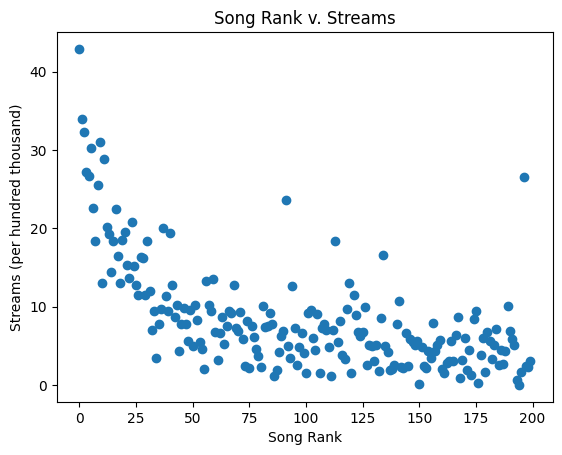

In [97]:
plt.scatter(range(0, len(song_count_series)), song_count_series.to_list())
plt.xlabel("Song Rank")
plt.ylabel("Streams (per hundred thousand)")
plt.title("Song Rank v. Streams")

## CSV

In [29]:
apple_csv = pd.read_csv("../all_data/apple_chart_concentration_measures.csv")

In [40]:
apple_csv.sort_values("HHI", ascending=False)

,chart_name,HHI,CR3,Gini
0,CÃ´te d'Ivoire Apple Music Top Song,0.087850,0.4025,0.600479
1,China Apple Music Top Song,0.078575,0.3750,0.556169
2,Israel Apple Music Top Song,0.062350,0.3275,0.586754
3,Benin Apple Music Top Song,0.058687,0.3500,0.576703
4,Burkina Faso Apple Music Top Song,0.052550,0.3200,0.399851
...,...,...,...,...
153,Solomon Islands Apple Music Top Song,0.009425,0.0925,0.362233
154,Ukraine Apple Music Top Song,0.009237,0.0775,0.250475
155,Yemen Apple Music Top Song,0.007412,0.0675,0.323659
156,Suriname Apple Music Top Song,0.006600,0.0575,0.310975


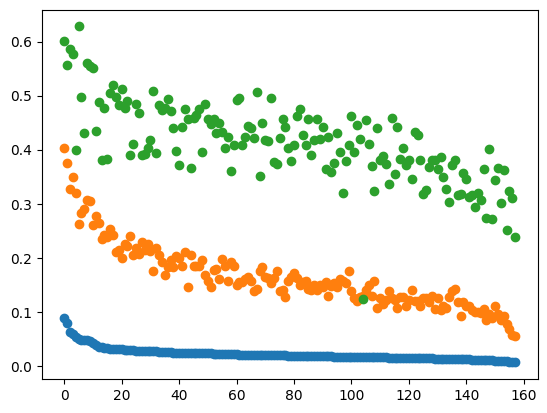

In [38]:
import matplotlib.pyplot as plt
plt.scatter(range(0, len(apple_csv)), apple_csv["HHI"])
plt.scatter(range(0, len(apple_csv)), apple_csv["CR3"])
plt.scatter(range(0, len(apple_csv)), apple_csv["Gini"])

(array([32., 72., 35.,  8.,  2.,  5.,  2.,  0.,  1.,  1.]),
 array([0.0060875 , 0.01426375, 0.02244   , 0.03061625, 0.0387925 ,
        0.04696875, 0.055145  , 0.06332125, 0.0714975 , 0.07967375,
        0.08785   ]),
 <BarContainer object of 10 artists>)

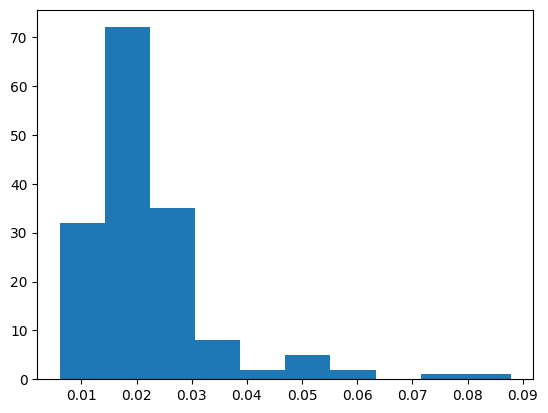

In [42]:
import matplotlib.pyplot as plt
plt.hist(apple_csv["HHI"])

(array([ 7., 30., 52., 29., 20.,  9.,  4.,  4.,  1.,  2.]),
 array([0.055  , 0.08975, 0.1245 , 0.15925, 0.194  , 0.22875, 0.2635 ,
        0.29825, 0.333  , 0.36775, 0.4025 ]),
 <BarContainer object of 10 artists>)

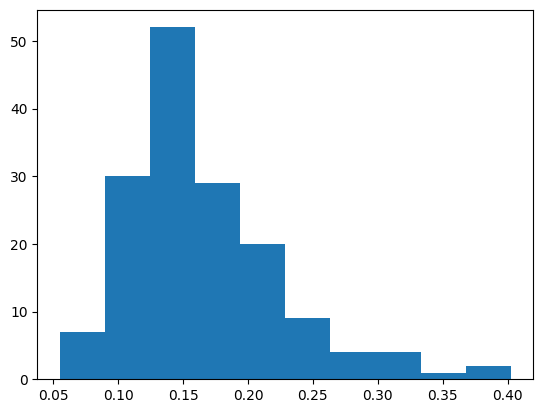

In [43]:
plt.hist(apple_csv["CR3"])

(array([ 1.,  0.,  4., 15., 25., 48., 39., 18.,  5.,  3.]),
 array([0.12436782, 0.17473509, 0.22510236, 0.27546963, 0.32583691,
        0.37620418, 0.42657145, 0.47693872, 0.527306  , 0.57767327,
        0.62804054]),
 <BarContainer object of 10 artists>)

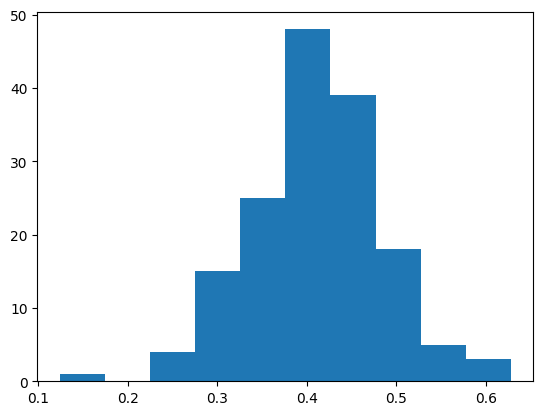

In [44]:
plt.hist(apple_csv["Gini"])